import libraries


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from imblearn.over_sampling import SMOTE

from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import f_classif, chi2
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

Read dataset

In [52]:
import os
import pandas as pd

DATA_PATH = os.path.join(os.getcwd(), "..", "dataset", "Churn_Modelling.csv")
df = pd.read_csv(DATA_PATH)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [53]:
# Adjsut col names
df.columns = df.columns.str.strip().str.replace(' ', '_')

In [54]:
# Drop first 3 features
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [56]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


EDA

In [57]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [58]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [59]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

data visulaize & handling outlier


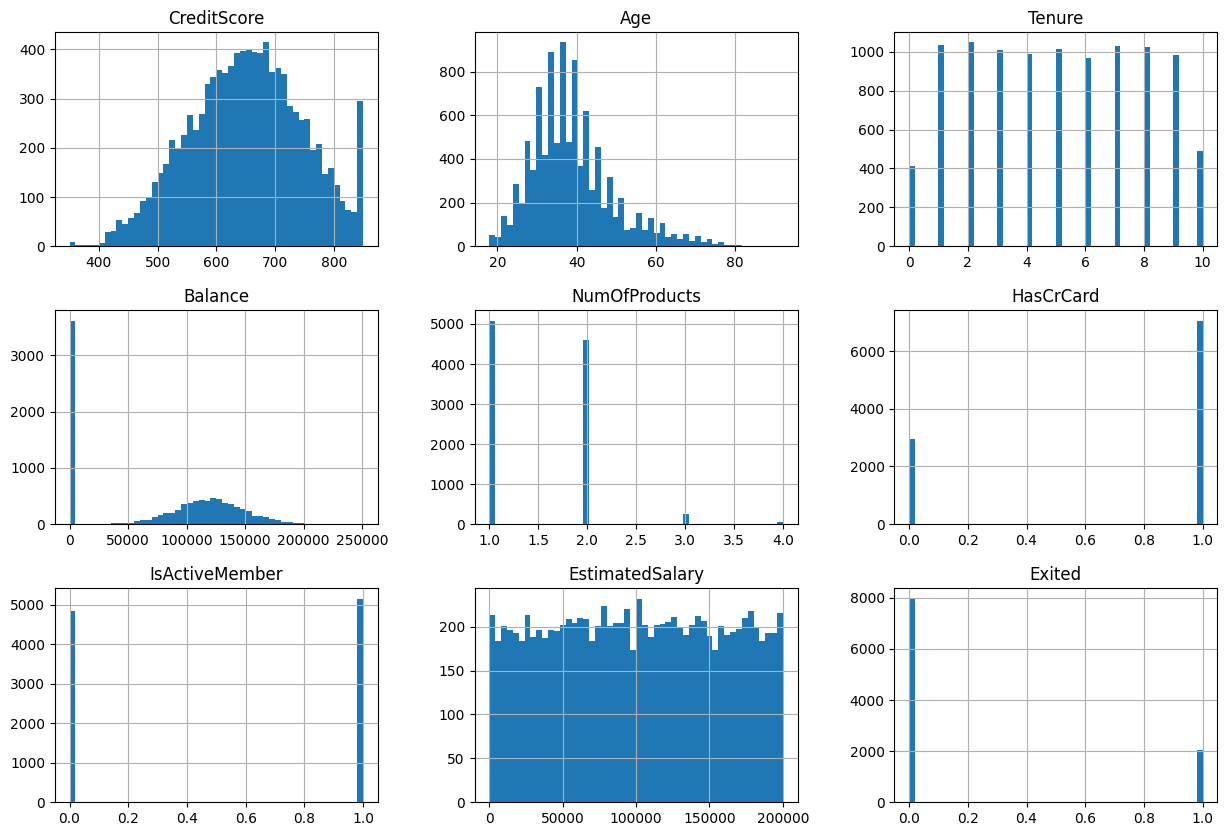

In [60]:
df.hist(bins=50, figsize=(15, 10))
plt.show()

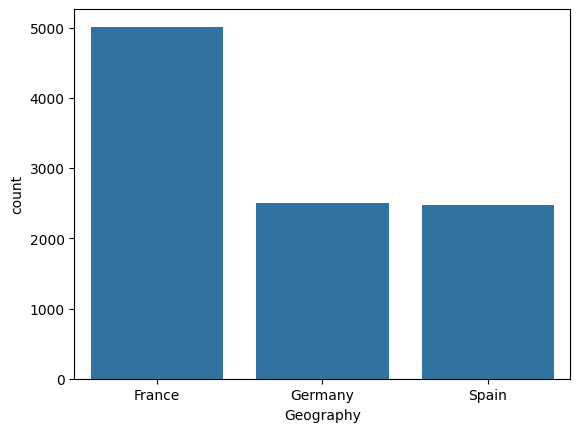

In [61]:
# countplot
sns.countplot(data=df, x='Geography', order=df['Geography'].value_counts().index.tolist())  ## title, xlabel, ylabel
plt.show()

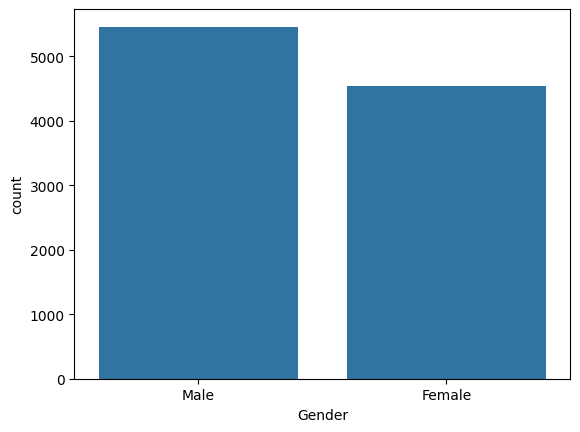

In [62]:
sns.countplot(data= df, x= 'Gender', order=df['Gender'].value_counts().index)
plt.show()

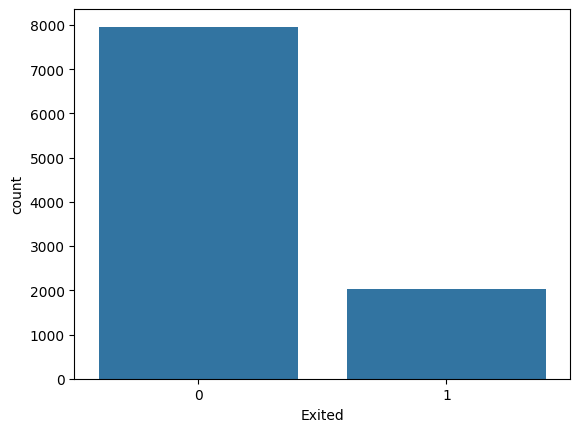

In [63]:
sns.countplot(data=df, x='Exited')
plt.show()

In [64]:
# Averge salary per Gender
df[['Gender', 'EstimatedSalary']].groupby('Gender')['EstimatedSalary'].mean()

Gender
Female    100601.541382
Male       99664.576931
Name: EstimatedSalary, dtype: float64

<Axes: xlabel='Gender', ylabel='EstimatedSalary'>

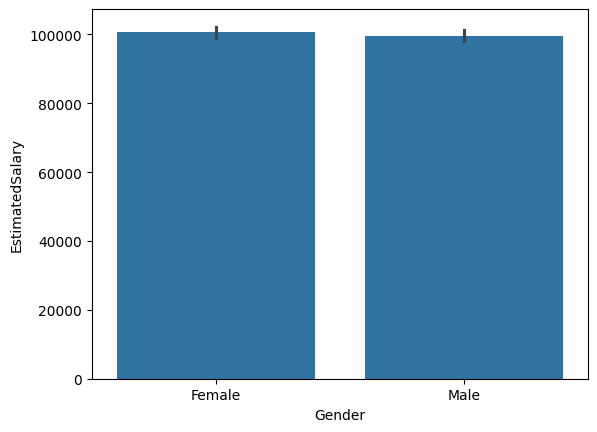

In [65]:
sns.barplot(data=df, y='EstimatedSalary', x='Gender', estimator='mean')

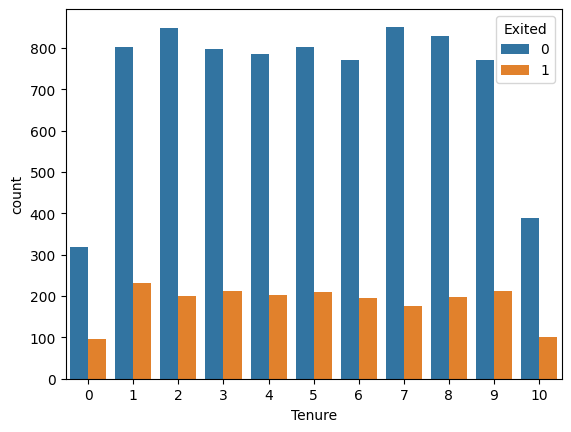

In [66]:
# Realation between Tenure and Exited
sns.countplot(data=df, x='Tenure', hue='Exited')  ## labels, title
plt.show()

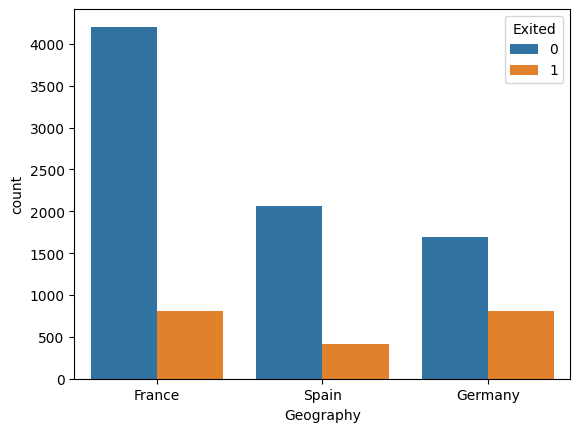

In [67]:
# Geography with Exited
sns.countplot(data=df,x='Geography', hue='Exited')  ## labels, titles
plt.show()

Split to train and test


In [68]:
# to featueres & target 
X = df.drop(columns=['Exited'], axis=1)
y = df['Exited']

# Split to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=45, stratify=y)

# Check shapes
print('X_train.shape \t', X_train.shape)
print('y_train.shape \t', y_train.shape)
print('***'*10)
print('X_test.shape \t', X_test.shape)
print('y_test.shape \t', y_test.shape)

X_train.shape 	 (8000, 10)
y_train.shape 	 (8000,)
******************************
X_test.shape 	 (2000, 10)
y_test.shape 	 (2000,)


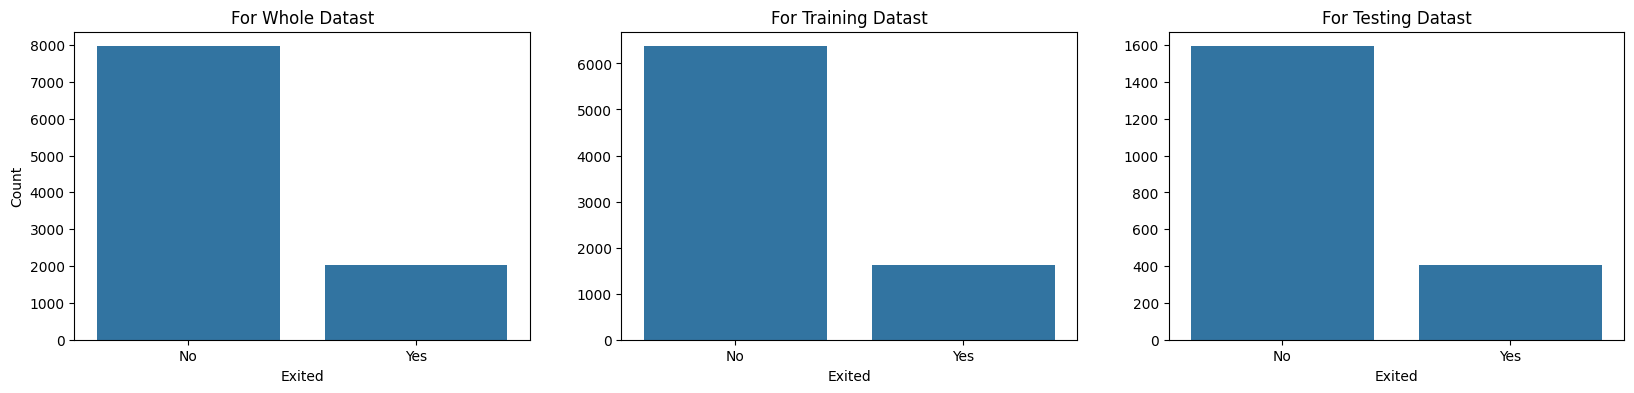

In [69]:
fig, ax = plt.subplots(1, 3, figsize=(20, 4))

plt.sca(ax[0])
sns.countplot(x=y)
plt.title('For Whole Datast')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

plt.sca(ax[1])
sns.countplot(x=y_train)
plt.title('For Training Datast')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

plt.sca(ax[2])
sns.countplot(x=y_test)
plt.title('For Testing Datast')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

plt.show()

Feature selection & preprossing


In [70]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [71]:
# slice cols
num_cols = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']
categ_cols = ['Gender', 'Geography']
ready_cols = list(set(X_train.columns.tolist()) - set(num_cols) - set(categ_cols))

In [72]:
# Numerical cols (num_cols) & Target cols --> ANOVA

_, p_val = f_classif(X_train[num_cols], y_train)
anova_result = pd.DataFrame({
    "Feature": num_cols,
    "P-Value": p_val
})

anova_result = anova_result.sort_values("P-Value")
print(anova_result)
# All features p-value less than 0.05 --> Reject H0 --> There is an asscociation

           Feature        P-Value
0              Age  4.539374e-151
2          Balance   4.930615e-27
1      CreditScore   9.934160e-02
3  EstimatedSalary   3.778856e-01


In [73]:
# Categorical cols (categ_cols) & Target cols --> chi2
_, p_val2 = chi2(X=OrdinalEncoder().fit_transform(X_train[categ_cols]), y=y_train)
chi2_result = pd.DataFrame({
    "Feature": categ_cols,
    "P-Value": p_val2
})
chi2_result = chi2_result.sort_values("P-Value")
print(chi2_result)
# All features p-value less than 0.05 --> Reject H0 --> There is an asscociation

     Feature       P-Value
0     Gender  2.106488e-11
1  Geography  1.192565e-03


In [74]:
# Ready cols (ready_cols) & Target cols --> chi2
_, p_val3 = chi2(X=X_train[ready_cols], y=y_train)
chi2_result2 = pd.DataFrame({
    "Feature": ready_cols,
    "P-Value": p_val3
})
chi2_result2 = chi2_result2.sort_values("P-Value")
print(chi2_result2)
# All features p-value less than 0.05 --> Reject H0 --> There is an asscociation

          Feature       P-Value
0  IsActiveMember  2.054425e-21
3          Tenure  6.520776e-02
1   NumOfProducts  1.379497e-01
2       HasCrCard  9.691931e-01


In [75]:
# Pipeline
# Numerical: num_cols --> Imputing using median, and standardscaler
# Categorical: categ_cols ---> Imputing using mode, and OHE
# Ready_cols ---> Imputing mode

# For Numerical
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For Categorical
categ_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# For Ready cols
ready_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine all
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_cols', num_pipeline, num_cols),
        ('categorical_cols', categ_pipeline, categ_cols),
        ('ready_cols', ready_pipeline, ready_cols)
    ]
)

# Apply to train and test
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [76]:
X_train_final.shape, y_train.shape

((8000, 13), (8000,))

In [77]:
feature_names = preprocessor.get_feature_names_out()

X_train_final = pd.DataFrame(
    X_train_final,
    columns=feature_names,
    index=X_train.index
)

In [78]:
X_train_final.head()

,numeric_cols__Age,numeric_cols__CreditScore,numeric_cols__Balance,numeric_cols__EstimatedSalary,categorical_cols__Gender_Female,categorical_cols__Gender_Male,categorical_cols__Geography_France,categorical_cols__Geography_Germany,categorical_cols__Geography_Spain,ready_cols__IsActiveMember,ready_cols__NumOfProducts,ready_cols__HasCrCard,ready_cols__Tenure
2161,-0.656695,-0.921961,1.459383,0.681872,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,6.0
7690,-0.752360,-0.839210,0.634542,0.787278,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4710,0.108628,-0.673707,1.386174,0.639831,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,3.0
8939,-0.465364,1.260602,-1.216815,1.228813,0.0,1.0,1.0,0.0,0.0,0.0,2.0,1.0,9.0
8734,0.778286,0.577905,1.094682,0.707667,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,10.0


In [79]:
# 2. Using SMOTE for over sampling
over = SMOTE(k_neighbors=5, sampling_strategy=0.7, random_state=45)
X_train_final_resampled, y_train_resampled = over.fit_resample(X_train_final, y_train)

In [80]:
# Create fodler for the models
MODELS_FOLDER_PATH = os.path.join(os.getcwd(), "..", "models")
os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)


In [81]:
# dump the preprocessor
joblib.dump(preprocessor, os.path.join(MODELS_FOLDER_PATH, 'preprocessor.pkl'))

['d:\\ML END TO END\\notebooks\\..\\models\\preprocessor.pkl']

Buliding Models

1. Logistic Regression

In [82]:
# Logistic Regression using SMOTE balanced data
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final_resampled, y_train_resampled)

# Predict and evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1_score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)


print(f'The f1_score using Logistic model for Training Dataset is {score_train_log*100:.3f}')
print(f'The f1_score using Logistic model for Testing Dataset is {score_test_log*100:.3f}')



The f1_score using Logistic model for Training Dataset is 49.837
The f1_score using Logistic model for Testing Dataset is 48.912


c:\Users\shaheen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

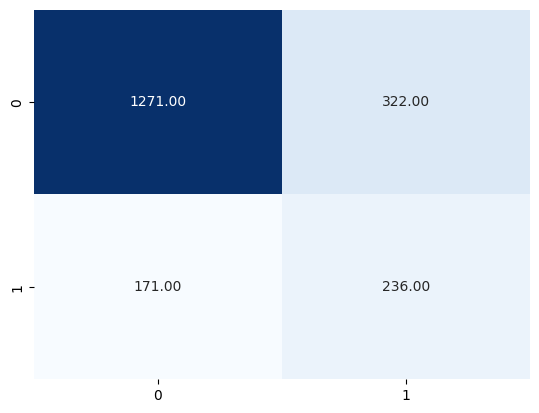

In [83]:
sns.heatmap(confusion_matrix(y_true=y_test, y_pred=y_pred_test_log), cmap='Blues', cbar=False, annot=True, fmt='.2f')

In [84]:
# clf report
print(classification_report(y_test, y_pred_test_log))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1593
           1       0.42      0.58      0.49       407

    accuracy                           0.75      2000
   macro avg       0.65      0.69      0.66      2000
weighted avg       0.79      0.75      0.77      2000



RandomForest

In [85]:
# Using RF -- With SMOTE
forst_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45)
forst_clf.fit(X_train_final_resampled, y_train_resampled)

# Predict and evaluate
y_pred_train_forest = forst_clf.predict(X_train_final)
y_pred_test_foerst = forst_clf.predict(X_test_final)

# Using f1_score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_foerst)

print(f'The f1_score using RF model for Training Dataset with SMOTE is {score_train_forest*100:.3f}')
print(f'The f1_score using RF model for Testing Dataset with SMOTE is {score_test_forest*100:.3f}')

The f1_score using RF model for Training Dataset with SMOTE is 62.447
The f1_score using RF model for Testing Dataset with SMOTE is 57.030


c:\Users\shaheen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


RF_Tuning


In [86]:
forest_base_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45)

# Your space to search
params_best_grid = {
            'n_estimators': np.arange(50, 400, 50),
            'max_depth': np.arange(6, 10, 2)
}

grid_search_forest = GridSearchCV(estimator=forest_base_clf, param_grid=params_best_grid, 
                                  cv=5, n_jobs=-1, verbose=4, scoring='f1')
grid_search_forest.fit(X_train_final_resampled, y_train_resampled)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


,estimator,RandomForestC...ndom_state=45)
,param_grid,"{'max_depth': array([6, 8]), 'n_estimators': array([ 50, 1...50, 300, 350])}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,np.int64(350)


In [87]:
# The best score according to your scoring & The best combination of what you search in
grid_search_forest.best_score_, grid_search_forest.best_params_

(np.float64(0.8070735097186781),
 {'max_depth': np.int64(8), 'n_estimators': np.int64(350)})

In [88]:
# The forest after tuning
forest_tuned = grid_search_forest.best_estimator_

# Predict and evaluate
y_pred_train_forest_tuned = forest_tuned.predict(X_train_final)
y_pred_test_forest_tuned = forest_tuned.predict(X_test_final)

# Using f1_score
score_train_forest_tuned = f1_score(y_train, y_pred_train_forest_tuned)
score_test_forest_tuned = f1_score(y_test, y_pred_test_forest_tuned)

print(f'The f1_score using tuned RF model for Training Dataset with class_weigths is {score_train_forest_tuned*100:.3f}')
print(f'The f1_score using tuned RF model for Testing Dataset with class_weigths is {score_test_forest_tuned*100:.3f}')

The f1_score using tuned RF model for Training Dataset with class_weigths is 66.218
The f1_score using tuned RF model for Testing Dataset with class_weigths is 58.270


c:\Users\shaheen\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [89]:
# Downlaod it if you are satisifed with the above model
joblib.dump(forest_tuned, os.path.join(MODELS_FOLDER_PATH, 'forest_tuned.pkl'))

['d:\\ML END TO END\\notebooks\\..\\models\\forest_tuned.pkl']

In [90]:
# Get the features out from the preprocessor
features_after = [name.split('__')[1] for name in preprocessor.get_feature_names_out()]
features_after

['Age',
 'CreditScore',
 'Balance',
 'EstimatedSalary',
 'Gender_Female',
 'Gender_Male',
 'Geography_France',
 'Geography_Germany',
 'Geography_Spain',
 'IsActiveMember',
 'NumOfProducts',
 'HasCrCard',
 'Tenure']

In [91]:
# Feature Importance from RF
forest_tuned_importance = pd.DataFrame({'feature': features_after, 
                              'importance': forest_tuned.feature_importances_}).sort_values('importance', ascending=False)
forest_tuned_importance

,feature,importance
0,Age,0.310339
10,NumOfProducts,0.248757
9,IsActiveMember,0.152718
7,Geography_Germany,0.063212
2,Balance,0.055112
6,Geography_France,0.028186
4,Gender_Female,0.025358
5,Gender_Male,0.024512
3,EstimatedSalary,0.020365
11,HasCrCard,0.019405


XGBoost

In [92]:
xgb_base_model = xgb.XGBClassifier(objective='binary:logistic', max_depth=5, 
                                 learning_rate=0.1, n_estimators=150, random_state=42)
xgb_base_model.fit(X_train_final_resampled, y_train_resampled)

# Predict and evaluate
y_pred_train_xgb = xgb_base_model.predict(X_train_final)
y_pred_test_xgb = xgb_base_model.predict(X_test_final)

# Using f1_score
score_train_xgb = f1_score(y_train, y_pred_train_xgb)
score_test_xgb = f1_score(y_test, y_pred_test_xgb)

print(f'The f1_score using XGBoost model for Training Dataset with scale is {score_train_xgb*100:.3f}')
print(f'The f1_score using XGBoost model for Testing Dataset with scale is {score_test_xgb*100:.3f}')

The f1_score using XGBoost model for Training Dataset with scale is 70.514
The f1_score using XGBoost model for Testing Dataset with scale is 61.538


In [98]:
# scale
scale = (y_train == 0).sum() / (y_train == 1).sum()


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = class_weights / np.sum(class_weights)
weight_dict = dict(zip(np.unique(y_train), class_weights))

sample_weights = np.array([weight_dict[y] for y in y_train])

In [99]:
xgb_base_model = xgb.XGBClassifier(objective='binary:logistic', max_depth=5, reg_lambda=5,
                                 learning_rate=0.1, n_estimators=150, random_state=4)

In [100]:
# Hyperparameter tuning with class weights
param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'n_estimators': [100, 200, 300, 400],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
}


random_search_xgb = RandomizedSearchCV(estimator=xgb_base_model, param_distributions=param_dist, 
                                       cv=5, n_jobs=-1, n_iter=25, scoring='f1', random_state=48)
random_search_xgb.fit(X_train_final, y_train, sample_weight=sample_weights)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,48
,error_score,nan


In [101]:
# The xgb after tuning
xgb_tuned = random_search_xgb.best_estimator_   ## The best model contains the best params you search in

# Predict and evaluate
y_pred_train_xgboost_tuned = xgb_tuned.predict(X_train_final)
y_pred_test_xgboost_tuned = xgb_tuned.predict(X_test_final)

# Using f1_score
score_train_xgb_tuned = f1_score(y_train, y_pred_train_xgboost_tuned)
score_test_xgb_tuned = f1_score(y_test, y_pred_test_xgboost_tuned)

print(f'The f1_score using tuned XGBoost model for Training Dataset with scale is {score_train_xgb_tuned*100:.3f}')
print(f'The f1_score using tuned XGBoost model for Testing Dataset with scale is {score_test_xgb_tuned*100:.3f}')

The f1_score using tuned XGBoost model for Training Dataset with scale is 64.585
The f1_score using tuned XGBoost model for Testing Dataset with scale is 60.451


In [102]:
# Dump model
joblib.dump(xgb_tuned, os.path.join(MODELS_FOLDER_PATH, 'xgb-tuned.pkl'))

['d:\\ML END TO END\\notebooks\\..\\models\\xgb-tuned.pkl']